In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

# Helper Functions

In [2]:
import pandas as pd

def reformat_allele(allele: str, resolution: int = 2) -> str:
    """
    Reformats an allele string to a standard format.
    For example, for two-field resolution:
      "A*01:03:XX" -> "A*01:03"
    For one-field resolution:
      "A*01:03" -> "A*01"
    """
    allele = allele.strip()
    if "*" not in allele:
        return allele
    gene, rest = allele.split("*", 1)
    fields = rest.split(":")
    if resolution == 1:
        return f"{gene}*{fields[0]}"
    elif resolution == 2:
        if len(fields) >= 2:
            return f"{gene}*{fields[0]}:{fields[1]}"
        else:
            return f"{gene}*{fields[0]}"
    else:
        return allele

def compare_allele_pair(gs_alleles: list, pre_alleles: list, resolution: int = 2) -> int:
    """
    Compares a pair of gold-standard alleles (list of two strings) 
    with a pair of predicted alleles.
    Returns the maximum number of matches (0, 1, or 2) by checking both 
    the parallel and cross comparisons.
    """
    gs_fmt = [reformat_allele(a, resolution) for a in gs_alleles]
    pre_fmt = [reformat_allele(a, resolution) for a in pre_alleles]
    
    parallel = (gs_fmt[0] == pre_fmt[0]) + (gs_fmt[1] == pre_fmt[1])
    cross = (gs_fmt[0] == pre_fmt[1]) + (gs_fmt[1] == pre_fmt[0])
    return max(parallel, cross)

def compare_allele_pair_filtered(gs_alleles: list, pre_alleles: list, valid_flags: list, resolution: int = 2) -> int:
    """
    Like compare_allele_pair, but only counts a predicted allele if it is valid.
    valid_flags is a list of booleans (one per allele) indicating whether the corresponding
    predicted allele passes the valid-set filter.
    For invalid predictions, that allele is treated as a "no call" (i.e. contributes 0 to the match).
    """
    gs_fmt = [reformat_allele(a, resolution) for a in gs_alleles]
    # For each predicted allele, only reformat it if it is valid; otherwise, set to None.
    pre_fmt = [reformat_allele(a, resolution) if valid else None for a, valid in zip(pre_alleles, valid_flags)]
    
    # For parallel comparison, count a match only if the predicted allele is valid.
    parallel = 0
    if pre_fmt[0] is not None and gs_fmt[0] == pre_fmt[0]:
        parallel += 1
    if pre_fmt[1] is not None and gs_fmt[1] == pre_fmt[1]:
        parallel += 1
    
    # Cross comparison.
    cross = 0
    if pre_fmt[1] is not None and gs_fmt[0] == pre_fmt[1]:
        cross += 1
    if pre_fmt[0] is not None and gs_fmt[1] == pre_fmt[0]:
        cross += 1
    return max(parallel, cross)

def get_dynamic_loci_from_gs(gs_df: pd.DataFrame) -> list:
    """
    Assumes the first column is a sample identifier.
    Every column after that corresponds to a locus.
    If a column name contains a '.1' suffix, it is removed.
    Returns a unique list of locus names.
    """
    loci = set()
    for col in gs_df.columns[1:]:
        # Remove any '.1' suffix
        locus = col.split('.')[0]
        loci.add(locus)
    return list(loci)

def calculate_accuracy(gs_file: str, pre_file: str, resolution: int = 2, filter_option: bool = False):
    """
    Reads the gold standard and prediction CSV files and computes overall accuracy,
    now including a no-calls category.

    Assumptions:
      - The gold-standard CSV (gs_file) has a "Run" column and columns for each locus.
        For each locus, there may be one column (e.g. "DRB1_gs") or two (e.g. "DRB1_gs" and "DRB1.1_gs").
      - The prediction CSV (pre_file) has an "ERR" column that matches the gold standard "Run" identifiers.
        For each locus, predictions are expected in a column named "{locus}_pre"; if a second prediction exists,
        it should be in a column named "{locus}.1_pre". If only one prediction is available for a diploid locus,
        it will be duplicated.
      
    filter_option: if True, only predicted alleles that appear in the gold-standard valid set (built from gs_file)
                   are counted in the accuracy calculation.
    
    Returns:
      A tuple:
        accuracy,            # (total_correct / total_calls)
        total_correct,       # number of matched alleles
        total_calls,         # total diploid calls (2 per locus that has gold-standard data)
        no_calls,            # how many alleles were not called at all
        miscalled_alleles    # list of gold-standard alleles that were miscalled
    """
    gs_df = pd.read_csv(gs_file)
    pre_df = pd.read_csv(pre_file)
    
    # Dynamically determine loci from the gold standard.
    loci = get_dynamic_loci_from_gs(gs_df)
    
    id_col_gs = gs_df.columns[0]
    id_col_pre = pre_df.columns[0]
    merged_df = pd.merge(gs_df, pre_df, left_on=id_col_gs, right_on=id_col_pre, suffixes=("_gs", "_pre"))
    
    total_correct = 0
    total_calls = 0
    no_calls = 0
    miscalled_alleles = []
    
    # Build valid allele sets for filtering if enabled.
    valid_set = {}
    if filter_option:
        valid_set = {locus: set() for locus in loci}
        for _, row in gs_df.iterrows():
            for col in gs_df.columns[1:]:
                locus = col.split('.')[0]
                if locus in loci:
                    gs_val = row[col]
                    if pd.isna(gs_val):
                        continue
                    for allele in str(gs_val).split("/"):
                        valid_set[locus].add(reformat_allele(allele.strip(), resolution))
    
    for _, row in merged_df.iterrows():
        for locus in loci:
            # Retrieve gold-standard alleles from all GS columns for this locus.
            gs_alleles_raw = []
            col1 = f"{locus}_gs"
            col2 = f"{locus}.1_gs"
            if col1 in row and not pd.isna(row[col1]):
                gs_alleles_raw.extend([a.strip() for a in str(row[col1]).split("/")])
            if col2 in row and not pd.isna(row[col2]):
                gs_alleles_raw.extend([a.strip() for a in str(row[col2]).split("/")])
            if not gs_alleles_raw:
                # No gold-standard allele => skip this locus entirely
                continue

            # Each locus is diploid => 2 calls
            total_calls += 2

            # Reformat the gold-standard alleles to a set
            gs_allele_set = set(reformat_allele(a, resolution) for a in gs_alleles_raw)
            # If more than two distinct alleles => ambiguous mode
            use_ambiguous = len(gs_allele_set) > 2

            if not use_ambiguous:
                gs_alleles = list(gs_allele_set)
                if len(gs_alleles) == 1:
                    # If there's only one distinct allele in the set, duplicate it
                    gs_alleles = [gs_alleles[0], gs_alleles[0]]
            
            # Gather predicted alleles
            pre_alleles = []
            pre_col1 = f"{locus}_pre"
            pre_col2 = f"{locus}.1_pre"
            if pre_col1 in row and not pd.isna(row[pre_col1]):
                pre_alleles.extend([a.strip() for a in str(row[pre_col1]).split("/")])
            if pre_col2 in row and not pd.isna(row[pre_col2]):
                pre_alleles.extend([a.strip() for a in str(row[pre_col2]).split("/")])
            
            # ---------------------
            # No-calls logic
            # ---------------------
            if len(pre_alleles) == 0:
                # No predicted alleles => 2 no-calls
                no_calls += 2
                # All miscalled
                miscalled_alleles.extend(gs_allele_set)
                continue
            elif len(pre_alleles) == 1:
                # If only one predicted allele => 1 no-call
                no_calls += 1
                # Duplicate the single allele for pairwise comparison
                pre_alleles = [pre_alleles[0], pre_alleles[0]]
            elif len(pre_alleles) > 2:
                # If more than two, keep only first two
                pre_alleles = pre_alleles[:2]
            
            if len(pre_alleles) != 2:
                # If we still don't have two predicted alleles, skip
                # (though the logic above should produce 2 if there's at least 1)
                miscalled_alleles.extend(gs_allele_set)
                continue
            
            # Compare predicted alleles to gold standard
            if use_ambiguous:
                # In ambiguous mode, each predicted allele is correct if it appears in gs_allele_set
                pred1 = reformat_allele(pre_alleles[0], resolution)
                pred2 = reformat_allele(pre_alleles[1], resolution)
                match_count = (1 if pred1 in gs_allele_set else 0) + (1 if pred2 in gs_allele_set else 0)
            else:
                match_count = compare_allele_pair(gs_alleles, pre_alleles, resolution)
            
            if filter_option:
                # Evaluate valid_flags
                valid_flags = []
                for allele in pre_alleles:
                    allele_fmt = reformat_allele(allele, resolution)
                    valid_flags.append(allele_fmt in valid_set[locus])
                
                valid_call_count = sum(valid_flags)
                
                # Overwrite the "match_count" with the filtered version if not ambiguous
                if not use_ambiguous:
                    match_count = compare_allele_pair_filtered(gs_alleles, pre_alleles, valid_flags, resolution)
                
                # total_calls was already incremented by 2 above
                # We'll only count valid predictions in the denominator if you prefer:
                # But typically we keep the 2 calls for diploid logic.
                
                total_correct += match_count
                if match_count < valid_call_count:
                    miscalled_alleles.extend(gs_allele_set)
            else:
                total_correct += match_count
                # We keep total_calls at 2
                if match_count < 2:
                    miscalled_alleles.extend(gs_allele_set)
    
    accuracy = total_correct / total_calls if total_calls > 0 else 0
    return accuracy, total_correct, total_calls, no_calls, miscalled_alleles


# Accuracy by Dataset

In [3]:
import pandas as pd

# List of tool names that you want to evaluate.
tools = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq", "hlahd"]
# Dataset numbers to iterate over.
dataset_nums = range(1, 9)

# List to store results.
results = []

# Loop over each tool and each dataset.
for tool in tools:
    for ds in dataset_nums:
        gs_file = f"../datasets/{ds}_gs.csv"          # Gold standard file for dataset ds.
        pre_file = f"../results/standard/{tool}_d{ds}.csv"  # Prediction file for the tool on dataset ds.
        try:
            # Call the updated accuracy function, which returns (accuracy, total_correct, total_calls, no_calls, miscalled_alleles).
            accuracy, correct, calls, no_calls, miscalled = calculate_accuracy(
                gs_file,
                pre_file,
                resolution=2,
                filter_option=False
            )
            # Append the results to our list
            results.append({
                "Tool": tool,
                "Dataset": ds,
                "Accuracy": accuracy,
                "CorrectCalls": correct,
                "TotalCalls": calls,
                "NoCalls": no_calls,
                "NumMiscalled": len(miscalled)
            })
            print(f"Processed {tool} on dataset {ds}: Accuracy = {accuracy:.3f}")
        except Exception as e:
            print(f"Error processing {tool} on dataset {ds}: {e}")

# Convert the results list to a DataFrame
df_results = pd.DataFrame(results)
print("\nSummary of Accuracy Evaluations:")
print(df_results)

# Optionally, save to a CSV file
# df_results.to_csv("accuracy_summary.csv", index=False)


Processed arcas on dataset 1: Accuracy = 0.937
Processed arcas on dataset 2: Accuracy = 0.948
Processed arcas on dataset 3: Accuracy = 0.677
Processed arcas on dataset 4: Accuracy = 0.143
Processed arcas on dataset 5: Accuracy = 1.000
Processed arcas on dataset 6: Accuracy = 1.000
Processed arcas on dataset 7: Accuracy = 0.150
Error processing arcas on dataset 8: [Errno 2] No such file or directory: '../results/standard/arcas_d8.csv'
Processed optitype on dataset 1: Accuracy = 0.982
Processed optitype on dataset 2: Accuracy = 0.000
Processed optitype on dataset 3: Accuracy = 0.940
Processed optitype on dataset 4: Accuracy = 0.000
Processed optitype on dataset 5: Accuracy = 0.625
Processed optitype on dataset 6: Accuracy = 1.000
Processed optitype on dataset 7: Accuracy = 0.263
Error processing optitype on dataset 8: [Errno 2] No such file or directory: '../results/standard/optitype_d8.csv'
Processed seq2hla on dataset 1: Accuracy = 0.920
Processed seq2hla on dataset 2: Accuracy = 0.292

# Bulk Accuracy

In [4]:
import pandas as pd

# List of tool names that you want to evaluate.
tools = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hla_vbseq", "hlahd", "hisat_genotype"]
# Dataset numbers to iterate over.
dataset_nums = range(1, 9)

# Lists to store per-dataset results for each resolution/filter combination.
results_2field = []
results_1field = []
results_2field_filtered = []
results_1field_filtered = []

# Loop over each tool and each dataset.
for tool in tools:
    for ds in dataset_nums:
        gs_file = f"../datasets/{ds}_gs.csv"          # Gold standard file for dataset ds.
        pre_file = f"../results/standard/{tool}_d{ds}.csv"  # Prediction file for the tool on dataset ds.
        try:
            # Call the updated accuracy function, returning:
            # (accuracy, total_correct, total_calls, no_calls, miscalled_alleles).
            accuracy_2field, correct_2field, calls_2field, no_calls_2field, miscalled_2field = calculate_accuracy(
                gs_file, pre_file, resolution=2, filter_option=False
            )
            accuracy_1field, correct_1field, calls_1field, no_calls_1field, miscalled_1field = calculate_accuracy(
                gs_file, pre_file, resolution=1, filter_option=False
            )
            accuracy_2field_filt, correct_2field_filt, calls_2field_filt, no_calls_2field_filt, miscalled_2field_filt = calculate_accuracy(
                gs_file, pre_file, resolution=2, filter_option=True
            )
            accuracy_1field_filt, correct_1field_filt, calls_1field_filt, no_calls_1field_filt, miscalled_1field_filt = calculate_accuracy(
                gs_file, pre_file, resolution=1, filter_option=True
            )

            # Store the results for 2-field (unfiltered)
            results_2field.append({
                "Tool": tool,
                "Dataset": ds,
                "Accuracy": accuracy_2field,
                "CorrectCalls": correct_2field,
                "TotalCalls": calls_2field,
                "NoCalls": no_calls_2field,
                "NumMiscalled": len(miscalled_2field)
            })

            # Store the results for 1-field (unfiltered)
            results_1field.append({
                "Tool": tool,
                "Dataset": ds,
                "Accuracy": accuracy_1field,
                "CorrectCalls": correct_1field,
                "TotalCalls": calls_1field,
                "NoCalls": no_calls_1field,
                "NumMiscalled": len(miscalled_1field)
            })

            # Store the results for 2-field (filtered)
            results_2field_filtered.append({
                "Tool": tool,
                "Dataset": ds,
                "Accuracy": accuracy_2field_filt,
                "CorrectCalls": correct_2field_filt,
                "TotalCalls": calls_2field_filt,
                "NoCalls": no_calls_2field_filt,
                "NumMiscalled": len(miscalled_2field_filt)
            })

            # Store the results for 1-field (filtered)
            results_1field_filtered.append({
                "Tool": tool,
                "Dataset": ds,
                "Accuracy": accuracy_1field_filt,
                "CorrectCalls": correct_1field_filt,
                "TotalCalls": calls_1field_filt,
                "NoCalls": no_calls_1field_filt,
                "NumMiscalled": len(miscalled_1field_filt)
            })

            # Print summary for each run
            print(f"Processed {tool} on dataset {ds} - 2field: {accuracy_2field:.3f}, 1field: {accuracy_1field:.3f}, "
                  f"2field_filt: {accuracy_2field_filt:.3f}, 1field_filt: {accuracy_1field_filt:.3f}")

        except Exception as e:
            print(f"Error processing {tool} on dataset {ds}: {e}")

# Convert per-dataset results to DataFrames.
df_2field = pd.DataFrame(results_2field)
df_1field = pd.DataFrame(results_1field)
df_2field_filt = pd.DataFrame(results_2field_filtered)
df_1field_filt = pd.DataFrame(results_1field_filtered)

print("\nPer-dataset Accuracy Evaluations (2-field, unfiltered):")
print(df_2field.head())
print("\nPer-dataset Accuracy Evaluations (1-field, unfiltered):")
print(df_1field.head())
# ... etc.

# Now, group the results by tool to compute bulk accuracy for each scenario.
# We sum CorrectCalls, TotalCalls, and NoCalls. Then we compute BulkAccuracy = CorrectCalls / TotalCalls.
# Optionally, compute a NoCallRate = NoCalls / TotalCalls.

def compute_bulk_accuracy(df):
    grouped = df.groupby("Tool").agg({
        "CorrectCalls": "sum",
        "TotalCalls": "sum",
        "NoCalls": "sum"
    }).reset_index()
    grouped["BulkAccuracy"] = grouped["CorrectCalls"] / grouped["TotalCalls"]
    grouped["NoCallRate"] = grouped["NoCalls"] / grouped["TotalCalls"]
    # Convert to percentages if you want
    grouped["BulkAccuracy%"] = grouped["BulkAccuracy"] * 100
    grouped["NoCallRate%"] = grouped["NoCallRate"] * 100
    return grouped

bulk_2field = compute_bulk_accuracy(df_2field)
bulk_1field = compute_bulk_accuracy(df_1field)
bulk_2field_filt = compute_bulk_accuracy(df_2field_filt)
bulk_1field_filt = compute_bulk_accuracy(df_1field_filt)

print("\nBulk Accuracy (2-field, unfiltered):")
print(bulk_2field)
print("\nBulk Accuracy (1-field, unfiltered):")
print(bulk_1field)
print("\nBulk Accuracy (2-field, filtered):")
print(bulk_2field_filt)
print("\nBulk Accuracy (1-field, filtered):")
print(bulk_1field_filt)

# Optionally, save results to CSV files:
# df_2field.to_csv("results_2field.csv", index=False)
# bulk_2field.to_csv("bulk_2field.csv", index=False)



Processed arcas on dataset 1 - 2field: 0.937, 1field: 0.991, 2field_filt: 0.937, 1field_filt: 0.991
Processed arcas on dataset 2 - 2field: 0.948, 1field: 0.977, 2field_filt: 0.948, 1field_filt: 0.977
Processed arcas on dataset 3 - 2field: 0.677, 1field: 0.970, 2field_filt: 0.677, 1field_filt: 0.970
Processed arcas on dataset 4 - 2field: 0.143, 1field: 0.143, 2field_filt: 0.143, 1field_filt: 0.143
Processed arcas on dataset 5 - 2field: 1.000, 1field: 1.000, 2field_filt: 1.000, 1field_filt: 1.000
Processed arcas on dataset 6 - 2field: 1.000, 1field: 1.000, 2field_filt: 1.000, 1field_filt: 1.000
Processed arcas on dataset 7 - 2field: 0.150, 1field: 0.295, 2field_filt: 0.150, 1field_filt: 0.295
Error processing arcas on dataset 8: [Errno 2] No such file or directory: '../results/standard/arcas_d8.csv'
Processed optitype on dataset 1 - 2field: 0.982, 1field: 0.997, 2field_filt: 0.982, 1field_filt: 0.997
Processed optitype on dataset 2 - 2field: 0.000, 1field: 0.000, 2field_filt: 0.000, 1fie

In [13]:
bulk_2field

,Tool,CorrectCalls,TotalCalls,NoCalls,BulkAccuracy,NoCallRate,BulkAccuracy%,NoCallRate%
0,arcas,5016,5624,140,0.891892,0.024893,89.189189,2.489331
1,hlahd,5050,5424,271,0.931047,0.049963,93.104720,4.996313
2,hlaminer,437,5584,254,0.078259,0.045487,7.825931,4.548711
3,optitype,3217,3378,68,0.952339,0.020130,95.233866,2.013025
4,phlat,4464,5410,12,0.825139,0.002218,82.513863,0.221811
5,seq2hla,4778,5420,12,0.881550,0.002214,88.154982,0.221402


In [14]:
bulk_1field

,Tool,CorrectCalls,TotalCalls,NoCalls,BulkAccuracy,NoCallRate,BulkAccuracy%,NoCallRate%
0,arcas,5402,5624,140,0.960526,0.024893,96.052632,2.489331
1,hlahd,5340,5424,271,0.984513,0.049963,98.451327,4.996313
2,hlaminer,1343,5584,254,0.240509,0.045487,24.050860,4.548711
3,optitype,3275,3378,68,0.969509,0.020130,96.950858,2.013025
4,phlat,4894,5410,12,0.904621,0.002218,90.462107,0.221811
5,seq2hla,5181,5420,12,0.955904,0.002214,95.590406,0.221402


In [5]:
bulk_1field['type']='pre-filter'
bulk_1field_filt['type']='filtered'
field_1_df=pd.concat([bulk_1field,bulk_1field_filt])

bulk_2field['type']='pre-filter'
bulk_2field_filt['type']='filtered'
field_2_df=pd.concat([bulk_2field,bulk_2field_filt])



In [16]:
field_2_df

,Tool,CorrectCalls,TotalCalls,NoCalls,BulkAccuracy,NoCallRate,BulkAccuracy%,NoCallRate%,type
0,arcas,5016,5624,140,0.891892,0.024893,89.189189,2.489331,pre-filter
1,hlahd,5050,5424,271,0.931047,0.049963,93.104720,4.996313,pre-filter
2,hlaminer,437,5584,254,0.078259,0.045487,7.825931,4.548711,pre-filter
3,optitype,3217,3378,68,0.952339,0.020130,95.233866,2.013025,pre-filter
4,phlat,4464,5410,12,0.825139,0.002218,82.513863,0.221811,pre-filter
5,seq2hla,4778,5420,12,0.881550,0.002214,88.154982,0.221402,pre-filter
0,arcas,5016,5624,140,0.891892,0.024893,89.189189,2.489331,filtered
1,hlahd,5050,5424,271,0.931047,0.049963,93.104720,4.996313,filtered
2,hlaminer,437,5584,254,0.078259,0.045487,7.825931,4.548711,filtered
3,optitype,3217,3378,68,0.952339,0.020130,95.233866,2.013025,filtered


## bulk accuracy by class

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# 1) Helper Functions
# --------------------------
classI_loci = {"A", "B", "C"}
classII_loci = {"DRB1", "DQB1"}

def reformat_allele(allele: str, resolution: int = 2) -> str:
    """
    Reformats an allele string to a standard format.
    For two-field resolution:
      "A*01:03:XX" -> "A*01:03"
    For one-field resolution:
      "A*01:03" -> "A*01"
    """
    allele = allele.strip()
    if "*" not in allele:
        return allele
    gene, rest = allele.split("*", 1)
    fields = rest.split(":")
    if resolution == 1:
        return f"{gene}*{fields[0]}"
    elif resolution == 2:
        if len(fields) >= 2:
            return f"{gene}*{fields[0]}:{fields[1]}"
        else:
            return f"{gene}*{fields[0]}"
    else:
        return allele

def compare_allele_pair(gs_alleles: list, pre_alleles: list, resolution: int = 2) -> int:
    """
    Standard pairwise comparison of a pair of gold-standard alleles (list of two strings)
    with a pair of predicted alleles (list of two strings).
    Returns the maximum number of matches (0, 1, or 2) by checking both parallel and cross.
    """
    gs_fmt = [reformat_allele(a, resolution) for a in gs_alleles]
    pre_fmt = [reformat_allele(a, resolution) for a in pre_alleles]
    parallel = (gs_fmt[0] == pre_fmt[0]) + (gs_fmt[1] == pre_fmt[1])
    cross = (gs_fmt[0] == pre_fmt[1]) + (gs_fmt[1] == pre_fmt[0])
    return max(parallel, cross)

def compare_allele_pair_filtered(gs_alleles: list, pre_alleles: list, valid_flags: list, resolution: int = 2) -> int:
    """
    Like compare_allele_pair, but only counts a predicted allele if it is valid.
    valid_flags is a list of booleans (one per allele) indicating whether the corresponding
    predicted allele passes the valid-set filter.
    For invalid predictions, that allele is treated as a "no call" (i.e. contributes 0 to the match).
    """
    gs_fmt = [reformat_allele(a, resolution) for a in gs_alleles]
    pre_fmt = [reformat_allele(a, resolution) if valid else None for a, valid in zip(pre_alleles, valid_flags)]
    parallel = 0
    if pre_fmt[0] is not None and gs_fmt[0] == pre_fmt[0]:
        parallel += 1
    if pre_fmt[1] is not None and gs_fmt[1] == pre_fmt[1]:
        parallel += 1
    cross = 0
    if pre_fmt[1] is not None and gs_fmt[0] == pre_fmt[1]:
        cross += 1
    if pre_fmt[0] is not None and gs_fmt[1] == pre_fmt[0]:
        cross += 1
    return max(parallel, cross)

def get_dynamic_loci_from_gs(gs_df: pd.DataFrame) -> list:
    """
    Assumes the first column of gs_df is the sample identifier.
    Every column after that corresponds to a locus.
    If a column name contains a ".1" suffix, it is removed.
    Returns a unique list of locus names.
    """
    loci = set()
    for col in gs_df.columns[1:]:
        locus = col.split('.')[0]
        loci.add(locus)
    return list(loci)

def is_no_call(allele_str: str) -> bool:
    """
    Returns True if the allele string represents a no call.
    """
    if not allele_str or pd.isna(allele_str):
        return True
    s = allele_str.strip().lower()
    return (s == "" or s == "." or s == "nan")

# --------------------------
# 2) Main Bulk Accuracy by Class Function
#    (This code will be run twice, one with filter_option=False and one with filter_option=True)
# --------------------------

def run_bulk_accuracy_by_class(filter_option: bool, resolution: int = 2):
    """
    Loops over all tools and datasets, computing bulk accuracy by HLA class
    (Class I and Class II) and tracking no-calls. Returns a DataFrame with aggregated
    results for the given filter_option setting.
    """
    # Define tools and dataset numbers.
    tools = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq", "hlahd"]
    dataset_nums = range(1, 9)
    
    # Initialize counts for each tool and HLA class.
    tool_counts = {
        tool: {
            "I": {"correct": 0, "calls": 0, "no_calls": 0},
            "II": {"correct": 0, "calls": 0, "no_calls": 0}
        }
        for tool in tools
    }
    
    # If filtering is enabled, build valid allele sets from the gold standard per locus.
    # We'll build this per dataset inside the loop.
    
    for tool in tools:
        for ds in dataset_nums:
            gs_file = f"../datasets/{ds}_gs.csv"          
            pre_file = f"../results/standard/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_file)
                pre_df = pd.read_csv(pre_file)
                
                # Get dynamic loci from the GS file.
                loci = get_dynamic_loci_from_gs(gs_df)
                
                # If filtering is enabled, build a valid set from the GS file.
                valid_set = {}
                if filter_option:
                    valid_set = {locus: set() for locus in loci}
                    for _, row in gs_df.iterrows():
                        for col in gs_df.columns[1:]:
                            locus = col.split('.')[0]
                            if locus in loci:
                                gs_val = row[col]
                                if pd.isna(gs_val):
                                    continue
                                for allele in str(gs_val).split("/"):
                                    valid_set[locus].add(reformat_allele(allele.strip(), resolution))
                
                # Merge on sample identifier.
                id_col_gs = gs_df.columns[0]
                id_col_pre = pre_df.columns[0]
                merged_df = pd.merge(gs_df, pre_df, left_on=id_col_gs, right_on=id_col_pre,
                                     suffixes=("_gs", "_pre"))
                
                # Process each sample.
                for _, row in merged_df.iterrows():
                    for locus in loci:
                        # Determine class for the locus.
                        if locus in classI_loci:
                            cls = "I"
                        elif locus in classII_loci:
                            cls = "II"
                        else:
                            continue
                            
                        # Retrieve GS alleles from all GS columns for the locus.
                        gs_alleles_raw = []
                        col1 = f"{locus}_gs"
                        col2 = f"{locus}.1_gs"
                        if col1 in row and not pd.isna(row[col1]):
                            gs_alleles_raw.extend(a.strip() for a in str(row[col1]).split("/"))
                        if col2 in row and not pd.isna(row[col2]):
                            gs_alleles_raw.extend(a.strip() for a in str(row[col2]).split("/"))
                        if not gs_alleles_raw:
                            continue
                        
                        # Each locus contributes 2 diploid calls.
                        tool_counts[tool][cls]["calls"] += 2
                        
                        # Form the gold standard allele set.
                        gs_allele_set = set(reformat_allele(a, resolution) for a in gs_alleles_raw)
                        use_ambiguous = len(gs_allele_set) > 2
                        if not use_ambiguous:
                            gs_list = list(gs_allele_set)
                            if len(gs_list) == 1:
                                gs_list = [gs_list[0], gs_list[0]]
                        
                        # Retrieve predicted alleles.
                        pre_alleles = []
                        pre_col1 = f"{locus}_pre"
                        pre_col2 = f"{locus}.1_pre"
                        if pre_col1 in row and not pd.isna(row[pre_col1]):
                            pre_alleles.extend(a.strip() for a in str(row[pre_col1]).split("/"))
                        if pre_col2 in row and not pd.isna(row[pre_col2]):
                            pre_alleles.extend(a.strip() for a in str(row[pre_col2]).split("/"))
                        
                        # No predicted alleles => record 2 no-calls.
                        if len(pre_alleles) == 0:
                            tool_counts[tool][cls]["no_calls"] += 2
                            continue
                        elif len(pre_alleles) == 1:
                            tool_counts[tool][cls]["no_calls"] += 1
                            pre_alleles = [pre_alleles[0], pre_alleles[0]]
                        elif len(pre_alleles) > 2:
                            pre_alleles = pre_alleles[:2]
                        if len(pre_alleles) != 2:
                            continue
                            
                        # Check for individual predicted no-calls.
                        for i in range(2):
                            if is_no_call(pre_alleles[i]):
                                tool_counts[tool][cls]["no_calls"] += 1
                                pre_alleles[i] = None
                        
                        if all(a is None for a in pre_alleles):
                            continue
                            
                        # Compare predicted alleles to gold standard.
                        if use_ambiguous:
                            # Ambiguous mode: count a predicted allele as correct if it is in the GS set.
                            match_count = 0
                            for a in pre_alleles:
                                if a is not None and reformat_allele(a, resolution) in gs_allele_set:
                                    match_count += 1
                        else:
                            # Standard pairwise comparison.
                            valid_pre = [a if a is not None else "NO_CALL" for a in pre_alleles]
                            match_count = compare_allele_pair(gs_list, valid_pre, resolution)
                        
                        if filter_option:
                            # Adjust match count with filtering.
                            valid_flags = []
                            for a in pre_alleles:
                                allele_fmt = reformat_allele(a, resolution) if a is not None else None
                                valid_flags.append(allele_fmt in valid_set.get(locus, set()) if allele_fmt is not None else False)
                            valid_call_count = sum(valid_flags)
                            if not use_ambiguous:
                                match_count = compare_allele_pair_filtered(gs_list, pre_alleles, valid_flags, resolution)
                            # Note: total calls remain 2 (diploid) per locus.
                        
                        tool_counts[tool][cls]["correct"] += match_count
                        
            except Exception as e:
                print(f"Error processing {tool} on dataset {ds}: {e}")
    
    # Aggregate counts into a list of rows.
    rows = []
    for tool in tools:
        for cls in ["I", "II"]:
            correct = tool_counts[tool][cls]["correct"]
            calls = tool_counts[tool][cls]["calls"]
            no_calls = tool_counts[tool][cls]["no_calls"]
            bulk_accuracy = correct / calls if calls > 0 else 0
            no_call_rate = no_calls / calls if calls > 0 else 0
            rows.append({
                "Tool": tool,
                "Class": cls,
                "CorrectCalls": correct,
                "TotalCalls": calls,
                "NoCalls": no_calls,
                "BulkAccuracy": bulk_accuracy,
                "BulkAccuracy%": bulk_accuracy * 100,
                "NoCallRate": no_call_rate,
                "NoCallRate%": no_call_rate * 100
            })
    
    df_bulk = pd.DataFrame(rows)
    return df_bulk

# --------------------------
# 3) Run Both Modes: Unfiltered and Filtered
# --------------------------
df_bulk_unfiltered = run_bulk_accuracy_by_class(filter_option=False, resolution=2)
df_bulk_filtered   = run_bulk_accuracy_by_class(filter_option=True, resolution=2)
#df_bulk_unfiltered
df_bulk_filtered


Error processing arcas on dataset 8: [Errno 2] No such file or directory: '../results/standard/arcas_d8.csv'
Error processing optitype on dataset 8: [Errno 2] No such file or directory: '../results/standard/optitype_d8.csv'
Error processing seq2hla on dataset 7: [Errno 2] No such file or directory: '../results/standard/seq2hla_d7.csv'
Error processing seq2hla on dataset 8: [Errno 2] No such file or directory: '../results/standard/seq2hla_d8.csv'
Error processing hlaminer on dataset 8: [Errno 2] No such file or directory: '../results/standard/hlaminer_d8.csv'
Error processing phlat on dataset 7: [Errno 2] No such file or directory: '../results/standard/phlat_d7.csv'
Error processing phlat on dataset 8: [Errno 2] No such file or directory: '../results/standard/phlat_d8.csv'
Error processing hlavbseq on dataset 8: [Errno 2] No such file or directory: '../results/standard/hlavbseq_d8.csv'
Error processing hlahd on dataset 7: [Errno 2] No such file or directory: '../results/standard/hlahd_d

,Tool,Class,CorrectCalls,TotalCalls,NoCalls,BulkAccuracy,BulkAccuracy%,NoCallRate,NoCallRate%
0,arcas,I,3008,3384,84,0.888889,88.888889,0.024823,2.482270
1,arcas,II,2008,2240,56,0.896429,89.642857,0.025000,2.500000
2,optitype,I,3217,3378,68,0.952339,95.233866,0.020130,2.013025
3,optitype,II,0,0,0,0.000000,0.000000,0.000000,0.000000
4,seq2hla,I,3032,3264,12,0.928922,92.892157,0.003676,0.367647
5,seq2hla,II,1746,2156,0,0.809833,80.983302,0.000000,0.000000
6,hlaminer,I,206,3360,132,0.061310,6.130952,0.039286,3.928571
7,hlaminer,II,231,2224,122,0.103867,10.386691,0.054856,5.485612
8,phlat,I,2865,3264,12,0.877757,87.775735,0.003676,0.367647
9,phlat,II,1599,2146,0,0.745107,74.510718,0.000000,0.000000


# accuracy per locus per dataset

In [48]:
import pandas as pd

def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    fields = rest.split(":")
    if resolution == 1:
        return f"{gene}*{fields[0]}"
    if len(fields) >= 2:
        return f"{gene}*{fields[0]}:{fields[1]}"
    return f"{gene}*{fields[0]}"

def get_dynamic_loci_from_gs(gs_df: pd.DataFrame) -> list:
    loci = set()
    for col in gs_df.columns[1:]:
        loci.add(col.split(".")[0])
    return list(loci)

def scale_locus_accuracy_with_nocalls(
    tools:     list,
    dataset_nums: list,
    resolution:  int = 2,
    filter_option: bool = False
) -> pd.DataFrame:
    """
    Aggregates counts across all `dataset_nums` for each tool in `tools`.
    Returns a DataFrame with columns:
      Tool | Locus | CorrectAlleles | MiscalledAlleles | NoCallAlleles
    """
    # aggregator: tool -> locus -> counters
    agg = {tool:{} for tool in tools}

    for tool in tools:
        for ds in dataset_nums:
            gs_file  = f"../datasets/{ds}_gs.csv"
            pre_file = f"../results/standard/{tool}_d{ds}.csv"
            try:
                gs_df  = pd.read_csv(gs_file)
                pre_df = pd.read_csv(pre_file)
            except FileNotFoundError:
                continue

            loci = get_dynamic_loci_from_gs(gs_df)

            # build valid sets if filtering
            valid_set = {}
            if filter_option:
                for locus in loci:
                    vals = (
                        gs_df
                        .filter(regex=f"^{locus}(\\.1)?$")
                        .astype(str)
                        .stack()
                        .dropna()
                    )
                    s = set()
                    for v in vals:
                        for a in v.split("/"):
                            s.add(reformat_allele(a, resolution))
                    valid_set[locus] = s

            # merge on sample ID
            id_col = gs_df.columns[0]
            merged = pd.merge(
                gs_df, pre_df,
                left_on=id_col, right_on="ERR",
                suffixes=("_gs","_pre")
            )

            # ensure counters exist
            for locus in loci:
                agg[tool].setdefault(locus, {
                    "correct":0, "miscalled":0, "nocall":0
                })

            # walk every sample×locus
            for _, row in merged.iterrows():
                for locus in loci:
                    # gather GS alleles
                    raw = []
                    for col in (f"{locus}_gs", f"{locus}.1_gs"):
                        if col in row and pd.notna(row[col]):
                            raw += [x.strip() for x in str(row[col]).split("/")]
                    if not raw:
                        continue
                    gs_set = { reformat_allele(a, resolution) for a in raw }
                    if len(gs_set) > 2:
                        # skip phase-ambiguous cases
                        continue

                    # gather predictions
                    pr = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        if col in row and pd.notna(row[col]):
                            pr += [x.strip() for x in str(row[col]).split("/")]
                    # reduce to up to two
                    if len(pr) == 0:
                        pr_count = 0
                    elif len(pr) == 1:
                        pr = pr*2
                        pr_count = 2
                    else:
                        pr = pr[:2]
                        pr_count = 2

                    # apply filter
                    if filter_option and pr_count>0:
                        vs = valid_set.get(locus,set())
                        old_pr = pr[:]
                        pr = [a for a in pr if reformat_allele(a, resolution) in vs]
                        pr_count = len(pr)

                    # reformat predicted alleles
                    pr_fmt = [ reformat_allele(a, resolution) for a in pr ]

                    # compute counts
                    # no-call = positions where no prediction was made
                    no_call = 2 - pr_count
                    # correct = # of predictions that hit GS set
                    correct = sum(1 for a in pr_fmt if a in gs_set)
                    miscalled = pr_count - correct

                    # accumulate
                    agg[tool][locus]["correct"]  += correct
                    agg[tool][locus]["miscalled"] += miscalled
                    agg[tool][locus]["nocall"]   += no_call

    # build DataFrame
    rows = []
    for tool, loci_dict in agg.items():
        for locus, c in loci_dict.items():
            rows.append({
                "Tool": tool,
                "Locus": locus,
                "CorrectAlleles":  c["correct"],
                "MiscalledAlleles":c["miscalled"],
                "NoCallAlleles":   c["nocall"],
            })
    df = pd.DataFrame(rows)
    # optional: compute total attempts
    df["TotalAlleles"] = df["CorrectAlleles"] + df["MiscalledAlleles"] + df["NoCallAlleles"]
    df["Accuracy"]    = df["CorrectAlleles"] / df["TotalAlleles"]
    return df.sort_values(["Tool","Locus"])

# --- example usage ---
if __name__ == "__main__":
    tools = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat"]
    dataset_nums = list(range(1,9))
    df_locus_stats = scale_locus_accuracy_with_nocalls(
        tools, dataset_nums, resolution=2, filter_option=True
    )
df_locus_stats
    # Now you have per-tool, per-locus counts of correct, miscalled and no-calls.


,Tool,Locus,CorrectAlleles,MiscalledAlleles,NoCallAlleles,TotalAlleles,Accuracy
0,arcas,A,408,10,54,472,0.864407
2,arcas,B,412,12,84,508,0.811024
4,arcas,C,473,28,73,574,0.824042
3,arcas,DQB1,452,70,66,588,0.768707
1,arcas,DRB1,1080,19,59,1158,0.932642
35,hisat,A,390,2,40,432,0.902778
37,hisat,B,450,12,6,468,0.961538
39,hisat,C,449,28,57,534,0.840824
38,hisat,DQB1,472,68,8,548,0.861314
36,hisat,DRB1,1057,32,29,1118,0.945438


# misclassification rate

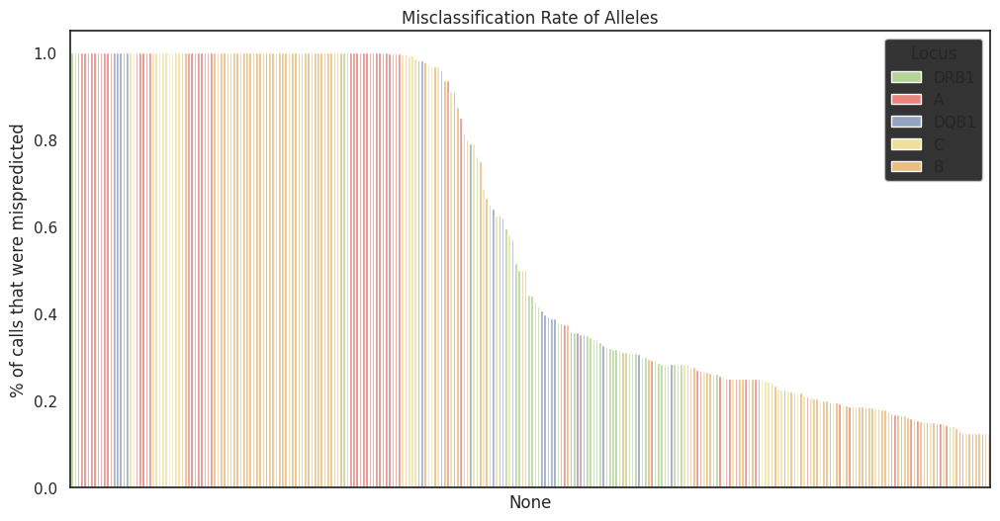

In [ ]:
import pandas as pd

def reformat_allele(allele: str) -> str:
    """Convert any allele string to two‑field resolution, e.g. 'A*01:03:XX' → 'A*01:03'."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if len(parts) >= 2:
        return f"{gene}*{parts[0]}:{parts[1]}"
    return f"{gene}*{parts[0]}"

def compute_allele_misclassification_rate(tools, dataset_nums):
    """
    Loops over each (tool, dataset), merges GS vs. predictions,
    and tallies for each two‑field allele at each locus:
      - total times it appears in GS
      - times it was NOT present in the predicted pair
    Returns a DataFrame with columns [Locus, Allele, MisclassificationRate].
    """
    # nested dict: locus -> allele -> {"total": int, "mis": int}
    tally = {}

    for tool in tools:
        for ds in dataset_nums:
            gs_file  = f"../datasets/{ds}_gs.csv"
            pre_file = f"../results/standard/{tool}_d{ds}.csv"
            try:
                gs_df  = pd.read_csv(gs_file)
                pre_df = pd.read_csv(pre_file)
            except FileNotFoundError:
                continue

            # merge on sample ID (first column of gs_df, 'ERR' in pre_df)
            id_col = gs_df.columns[0]
            merged = pd.merge(gs_df, pre_df, left_on=id_col, right_on="ERR",
                              suffixes=("_gs","_pre"), how="inner")

            # get loci dynamically
            loci = sorted({c.split(".")[0] for c in gs_df.columns if c!="ERR"})

            for _, row in merged.iterrows():
                for locus in loci:
                    # collect GS alleles (split on '/'), reformat each
                    raw = []
                    for col in (f"{locus}_gs", f"{locus}.1_gs"):
                        if col in row and pd.notna(row[col]):
                            raw += str(row[col]).split("/")
                    gs_alleles = [reformat_allele(a) for a in raw]
                    if not gs_alleles:
                        continue

                    # collect predicted alleles (up to 2), reformat
                    pr = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        if col in row and pd.notna(row[col]):
                            pr += str(row[col]).split("/")
                    if len(pr)==0:
                        pr_fmt = []
                    else:
                        pr = pr[:2] if len(pr)>2 else (pr*2 if len(pr)==1 else pr)
                        pr_fmt = [reformat_allele(a) for a in pr]

                    # tally
                    for allele in gs_alleles:
                        tally.setdefault(locus, {}).setdefault(allele, {"total":0,"mis":0})
                        tally[locus][allele]["total"] += 1
                        if allele not in pr_fmt:
                            tally[locus][allele]["mis"] += 1

    # build result DataFrame
    records = []
    for locus, alleles in tally.items():
        for allele, counts in alleles.items():
            total = counts["total"]
            mis   = counts["mis"]
            rate  = mis/total if total>0 else 0
            records.append({
                "Locus": locus,
                "Allele": allele,
                "MisclassificationRate": rate
            })
    df = pd.DataFrame(records)
    df = df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)
    return df

# --- example usage ---
if __name__ == "__main__":
    tools = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat"]
    datasets = list(range(1,9))
    df_misclassified = compute_allele_misclassification_rate(tools, datasets)



In [ ]:
import pandas as pd

def reformat_allele(allele: str) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if len(parts) >= 2:
        return f"{gene}*{parts[0]}:{parts[1]}"
    return f"{gene}*{parts[0]}"

def compute_allele_misclassification_rate_unambiguous(tools, dataset_nums):
    """
    Like before, but SKIPPING any GS cell containing "/" (phase ambiguity).
    """
    tally = {}  # locus -> allele -> {total, mis}

    for tool in tools:
        for ds in dataset_nums:
            gs_file, pre_file = f"../datasets/{ds}_gs.csv", f"../results/standard/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_file)
                pre_df = pd.read_csv(pre_file)
            except FileNotFoundError:
                continue

            id_col = gs_df.columns[0]
            merged = pd.merge(gs_df, pre_df,
                              left_on=id_col, right_on="ERR",
                              suffixes=("_gs","_pre"), how="inner")

            loci = sorted({c.split(".")[0] for c in gs_df.columns if c!=id_col})

            for _, row in merged.iterrows():
                for locus in loci:
                    # GS cell (unambiguous only!)
                    gs_val = row.get(f"{locus}_gs", "")
                    if not isinstance(gs_val, str) or "/" in gs_val:
                        continue

                    true_allele = reformat_allele(gs_val)

                    # gather predicted alleles
                    raw = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            raw += v.split("/")
                    if not raw:
                        # no‐call counts as a mis
                        mis = 1
                    else:
                        # reduce to two
                        if len(raw) == 1:
                            raw = raw*2
                        else:
                            raw = raw[:2]
                        preds = {reformat_allele(a) for a in raw}
                        mis = int(true_allele not in preds)

                    # tally
                    tally\
                        .setdefault(locus, {})\
                        .setdefault(true_allele, {"total":0, "mis":0})
                    tally[locus][true_allele]["total"] += 1
                    tally[locus][true_allele]["mis"]   += mis

    # build DataFrame
    recs = []
    for locus, alleles in tally.items():
        for allele, cnt in alleles.items():
            total, mis = cnt["total"], cnt["mis"]
            recs.append({
                "Locus": locus,
                "Allele": allele,
                "Total": total,
                "Misclassified": mis,
                "MisclassificationRate": mis/total if total else 0
            })
    df = pd.DataFrame(recs)
    return df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)

# Example usage
tools = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat"]
datasets = list(range(1,9))
df_misclassified = compute_allele_misclassification_rate_unambiguous(tools, datasets)
df_misclassified
# Now df_misclassified only counts truly unambiguous GS calls,
# and you can feed it into your bar‐plot code exactly as before.


,Locus,Allele,Total,Misclassified,MisclassificationRate
0,DRB1,DRB1*14:01,15,15,1.000000
1,DRB1,DRB1*09:01,2,2,1.000000
2,DRB1,,609,609,1.000000
3,DQB1,DQB1*06:05,15,15,1.000000
4,DQB1,,509,509,1.000000
...,...,...,...,...,...
130,A,A*02:11,8,2,0.250000
131,A,A*31:01,4,1,0.250000
132,A,A*26:01,24,5,0.208333
133,C,C*14:02,12,2,0.166667


In [76]:
import pandas as pd

def reformat_allele(allele: str) -> str:
    """Convert any HLA allele to two‑field (e.g. 'A*01:03:XX'→'A*01:03')."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if len(parts) >= 2:
        return f"{gene}*{parts[0]}:{parts[1]}"
    return f"{gene}*{parts[0]}"

def compute_allele_misclassification_rate_including_ambiguity(tools, dataset_nums):
    """
    Loops over each (tool, dataset), merges GS vs. predictions,
    and for every allele in every GS set (ambiguous or not):
      - increments `total`
      - if pred_set ∩ GS_set != ∅, increments `correct` for all in GS_set;
        else increments `mis` for all in GS_set.
    Returns DataFrame: [Locus, Allele, Total, Mis, MisclassificationRate].
    """
    # tally[locus][allele] = {"total":int, "mis":int}
    tally = {}

    for tool in tools:
        for ds in dataset_nums:
            gs_file, pre_file = f"../datasets/{ds}_gs.csv", f"../results/standard/{tool}_d{ds}.csv"
            try:
                gs_df  = pd.read_csv(gs_file)
                pre_df = pd.read_csv(pre_file)
            except FileNotFoundError:
                continue

            # merge on sample ID
            id_col = gs_df.columns[0]
            merged = pd.merge(gs_df, pre_df,
                              left_on=id_col, right_on="ERR",
                              suffixes=("_gs","_pre"),
                              how="inner")

            # dynamic loci
            loci = sorted({c.split(".")[0] for c in gs_df.columns if c!=id_col})

            for _, row in merged.iterrows():
                for locus in loci:
                    # 1) build GS_set (possibly ambiguous)
                    gvals = []
                    for col in (f"{locus}_gs", f"{locus}.1_gs"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            gvals += v.split("/")
                    if not gvals:
                        continue
                    gs_set = { reformat_allele(x) for x in gvals }

                    # 2) build predicted set
                    pvals = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            pvals += v.split("/")
                    # reduce to up to 2 : duplicate if only one, truncate if >2
                    if   len(pvals)==0:    pred_set = set()
                    elif len(pvals)==1:    pred_set = { reformat_allele(pvals[0]) }
                    else:
                        pred_set = { reformat_allele(x) for x in pvals[:2] }

                    # 3) decide correct vs mis for the entire GS_set
                    hit = bool(pred_set & gs_set)  # non‐empty intersection
                    # initialize tally
                    for allele in gs_set:
                        tally.setdefault(locus, {})\
                             .setdefault(allele, {"total":0, "mis":0})
                        tally[locus][allele]["total"] += 1
                        if not hit:
                            tally[locus][allele]["mis"] += 1

    # build DataFrame
    rows = []
    for locus, alleles in tally.items():
        for allele, cnt in alleles.items():
            total = cnt["total"]
            mis   = cnt["mis"]
            rate  = mis/total if total>0 else 0.0
            rows.append({
                "Locus": locus,
                "Allele": allele,
                "Total": total,
                "Mis": mis,
                "MisclassificationRate": rate
            })
    df = pd.DataFrame(rows)
    return df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)


# --- example usage ---
if __name__ == "__main__":
    tools = ["arcas","optitype","seq2HLA","hlaminer","phlat","hla_vbseq","hla_hd","hisat_genotype"]
    datasets= list(range(1,9))

    df_misclassified = compute_allele_misclassification_rate_including_ambiguity(
        tools, datasets
    )

df_misclassified
    # Now feed df_misclassified into your bar‐plot code:
    #
    # sns.barplot(x=df_misclassified.index,
    #             y="MisclassificationRate",
    #             hue="Locus",
    #             data=df_misclassified, …)


,Locus,Allele,Total,Mis,MisclassificationRate
0,DQB1,DQB1*06:05,21,19,0.904762
1,B,B*15:16,13,10,0.769231
2,B,B*55:xx,4,3,0.750000
3,C,C*18:02,10,6,0.600000
4,C,C*02:10,7,4,0.571429
...,...,...,...,...,...
279,B,B*40:97,32,5,0.156250
280,C,C*15:05,48,7,0.145833
281,A,A*03:03,8,1,0.125000
282,A,A*69:01,8,1,0.125000


# read length accuracy

In [158]:
import os
import pandas as pd

# -------------------------------------------------------
# 1) Helper to normalize any allele string to two‐field.
# -------------------------------------------------------
def reformat_allele(allele: str) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if len(parts) >= 2:
        return f"{gene}*{parts[0]}:{parts[1]}"
    return f"{gene}*{parts[0]}"

# -------------------------------------------------------
# 2) Compute accuracy by read length
# -------------------------------------------------------
def compute_readlength_accuracy(
    tools:       list,
    read_lengths:list,
    gs_file:     str  = "../datasets/readlength_gs.csv",
    results_dir: str  = "../results/read_length/standard"
) -> pd.DataFrame:
    """
    For each tool in `tools` and each read length in `read_lengths`:
      - load predictions from results_dir/{tool}_{rl}.csv
      - merge with gs_file on `Run` vs `ERR`
      - for each sample×locus, split GS ambiguities on '/', split predictions on '/',
        reformat to two‐field, and then count:
          total_calls   += 1 per predicted allele
          correct_calls += 1 if that allele is in the GS set
      - finally compute accuracy = correct_calls / total_calls
    Returns a DataFrame with columns:
      Tool | ReadLength | CorrectCalls | TotalCalls | Accuracy
    """
    # load the single GS file
    gs_df = pd.read_csv(gs_file)
    id_col = "Run"

    # dynamically find your loci
    loci = sorted({c.split(".")[0] for c in gs_df.columns if c != id_col})

    rows = []
    for tool in tools:
        for rl in read_lengths:
            pred_path = os.path.join(results_dir, f"{tool}_{rl}.csv")
            if not os.path.exists(pred_path):
                print(f"[!] Missing predictions: {pred_path}")
                continue

            pre_df = pd.read_csv(pred_path)
            merged = pd.merge(
                gs_df, pre_df,
                left_on=id_col, right_on="ERR",
                suffixes=("_gs","_pre"),
                how="inner"
            )

            correct_calls = 0
            total_calls   = 0

            for _, row in merged.iterrows():
                for locus in loci:
                    # build the GS set (allowing "/")
                    gvals = []
                    for col in (f"{locus}_gs", f"{locus}.1_gs"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            gvals += v.split("/")
                    if not gvals:
                        continue
                    gs_set = {reformat_allele(x) for x in gvals}

                    # build the predicted list (allowing "/")
                    pvals = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            pvals += v.split("/")
                    # if no call, skip this locus
                    if not pvals:
                        continue
                    # enforce exactly two tries
                    if len(pvals) == 1:
                        pvals = pvals * 2
                    else:
                        pvals = pvals[:2]

                    # reformat and tally
                    for allele in pvals:
                        reform = reformat_allele(allele)
                        total_calls += 1
                        if reform in gs_set:
                            correct_calls += 1

            accuracy = correct_calls / total_calls if total_calls else 0.0
            rows.append({
                "Tool":         tool,
                "ReadLength":   rl,
                "CorrectCalls": correct_calls,
                "TotalCalls":   total_calls,
                "Accuracy":     accuracy
            })

    return pd.DataFrame(rows)

# -------------------------------------------------------
# 3) Example invocation & quick plot
# -------------------------------------------------------
if __name__ == "__main__":
    tools        = ["arcas","optitype","seq2HLA",
                    "phlat","hlavbseq","hlahd","hisat"]
    read_lengths = [36, 51, 76, 101, 126]

    df_rl_acc = compute_readlength_accuracy(
        tools, read_lengths,
        gs_file="../datasets/readlength_gs.csv",
        results_dir="../results/read_length/standard"
    )
df_rl_acc

[!] Missing predictions: ../results/read_length/standard/seq2HLA_36.csv
[!] Missing predictions: ../results/read_length/standard/seq2HLA_51.csv
[!] Missing predictions: ../results/read_length/standard/seq2HLA_76.csv
[!] Missing predictions: ../results/read_length/standard/seq2HLA_101.csv
[!] Missing predictions: ../results/read_length/standard/seq2HLA_126.csv
[!] Missing predictions: ../results/read_length/standard/hisat_36.csv
[!] Missing predictions: ../results/read_length/standard/hisat_51.csv
[!] Missing predictions: ../results/read_length/standard/hisat_76.csv
[!] Missing predictions: ../results/read_length/standard/hisat_101.csv
[!] Missing predictions: ../results/read_length/standard/hisat_126.csv


,Tool,ReadLength,CorrectCalls,TotalCalls,Accuracy
0,arcas,36,32,48,0.666667
1,arcas,51,42,50,0.840000
2,arcas,76,49,50,0.980000
3,arcas,101,9,10,0.900000
4,arcas,126,9,10,0.900000
5,optitype,36,24,24,1.000000
6,optitype,51,24,24,1.000000
7,optitype,76,24,24,1.000000
8,optitype,101,0,0,0.000000
9,optitype,126,0,0,0.000000


# Figures

In [27]:
from matplotlib import colors as mcolors


# color palette
palette = [mcolors.to_rgba(c) for c in [ "#be6968", '#61ba40',"#6590ca",'coral','orange','gold','skyblue','cornflowerblue', '#e9af61',"#49adad" ] ]


/tmp/ipykernel_2729274/4163528951.py:5: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=field_1_df,x="Tool",y="BulkAccuracy%",ax=ax[0],hue="type",palette=palette)
/tmp/ipykernel_2729274/4163528951.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=field_2_df,x="Tool",y="BulkAccuracy%",ax=ax[1],hue="type",palette=palette)


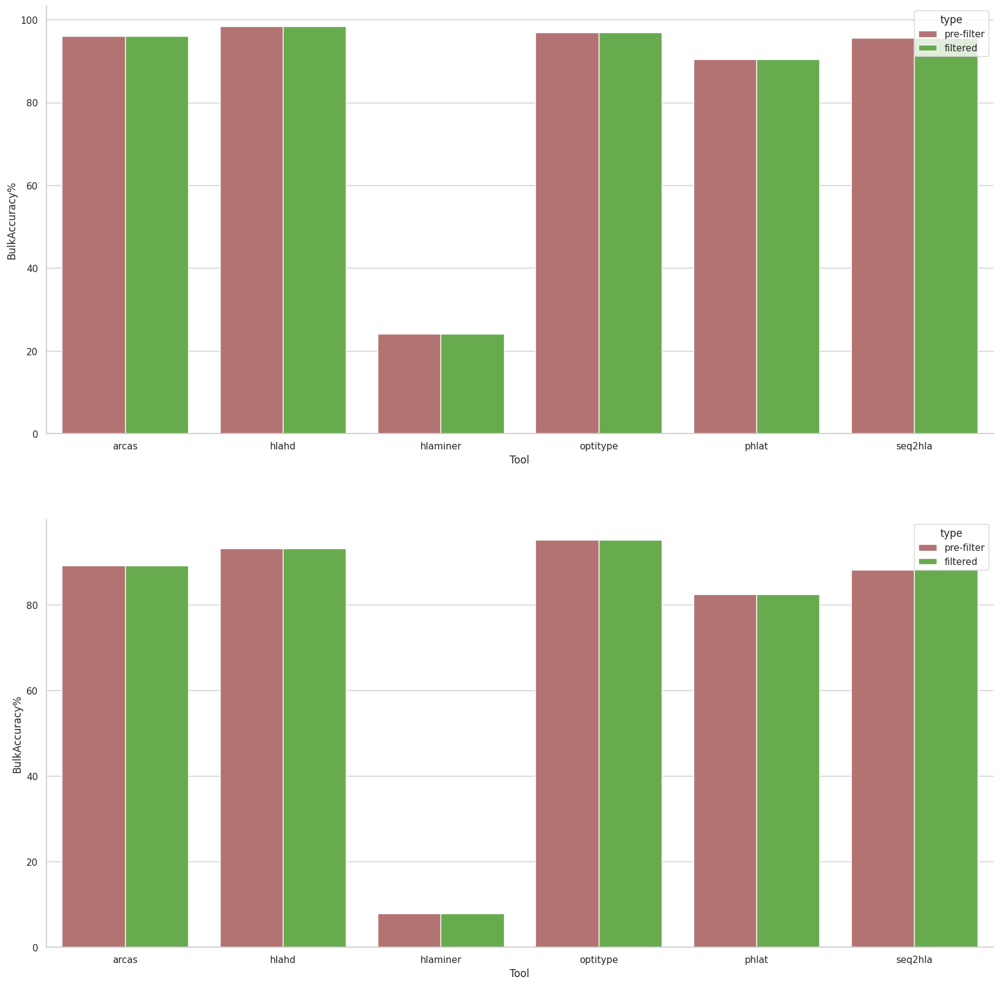

In [28]:
fig = plt.figure(figsize=(20,20))
#add some p value significance to this 
#left plot
ax=fig.subplots(2,1)
sns.barplot(data=field_1_df,x="Tool",y="BulkAccuracy%",ax=ax[0],hue="type",palette=palette)
sns.barplot(data=field_2_df,x="Tool",y="BulkAccuracy%",ax=ax[1],hue="type",palette=palette)
#sns.barplot(data=results_2field,x="Tool",y="BulkAccuracy%",ax=ax[0,0],hue="Tool",palette=palette)
#sns.barplot(data=results_1field,x="Tool",y="BulkAccuracy%",ax=ax[0,1],hue="Tool",palette=palette)
#sns.barplot(data=results_2field_filtered,x="Tool",y="BulkAccuracy%",ax=ax[1,0],hue="Tool",palette=palette)
#sns.barplot(data=results_1field_filtered,x="Tool",y="BulkAccuracy%",ax=ax[1,1],hue="Tool",palette=palette)
sns.despine()

## Figure 4: bulk accuracy by class vertical split

/tmp/ipykernel_2655419/144319365.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


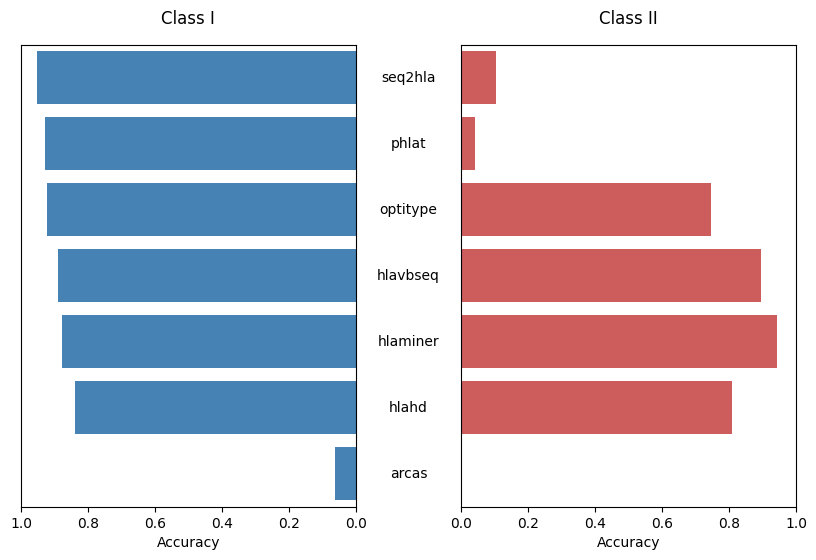

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose df is your DataFrame with columns: ["Tool", "I", "II"] containing
# Class I and Class II accuracies per tool, already sorted.
df=df_bulk_filtered.pivot_table(values="BulkAccuracy", index="Tool", columns="Class").reset_index().rename_axis(None, axis=1)
df=df.sort_values(by=["I", "II"], ascending=[False, False])
fig = plt.figure(figsize=(10, 6))
# Make the center axis quite narrow to minimize white space:
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 0.3, 1], wspace=0.01)

ax_left = fig.add_subplot(gs[0, 0])
ax_center = fig.add_subplot(gs[0, 1])
ax_right = fig.add_subplot(gs[0, 2])

# The y positions for each tool
y_positions = np.arange(len(df))

# -------------------------------
# Left axis: Class I
# -------------------------------
ax_left.barh(y_positions, df["I"], color="steelblue", align="center")
ax_left.set_ylim(-0.5, len(df) - 0.5)
ax_left.set_xlim(0, 1)
ax_left.invert_xaxis()   # so higher accuracy is near the center
ax_left.invert_yaxis()   # so the top row is the first item
ax_left.set_xlabel("Accuracy")
ax_left.set_title("Class I", pad=15)
# Hide y-ticks; we'll place labels in the center axis
ax_left.set_yticks([])
ax_left.set_yticklabels([])

# -------------------------------
# Center axis: narrow space for labels
# -------------------------------
# Match y-limits to the left, invert so the top is y=0
ax_center.set_ylim(ax_left.get_ylim())
ax_center.invert_yaxis()
# Remove all spines and ticks
for spine in ax_center.spines.values():
    spine.set_visible(False)
ax_center.set_xticks([])
ax_center.set_yticks([])

# Manually place each tool label near x=1.0 or 0.5, depending on your preference.
# We'll do x=0.5 so it's truly centered in the narrow subplot.
for i, row in df.iterrows():
    tool_name = row["Tool"]
    ax_center.text(
        0.5,         # x in [0..1] across the center axis
        i,           # y position
        tool_name,
        ha="center", # center horizontally
        va="center", # center vertically
        fontsize=10
    )

# -------------------------------
# Right axis: Class II
# -------------------------------
ax_right.barh(y_positions, df["II"], color="indianred", align="center")
ax_right.set_ylim(ax_left.get_ylim())
ax_right.invert_yaxis()
ax_right.set_xlim(0, 1)
ax_right.set_xlabel("Accuracy")
ax_right.set_title("Class II", pad=15)
# Hide y ticks (labels are in the center axis)
ax_right.set_yticks([])
ax_right.set_yticklabels([])

plt.tight_layout()
plt.show()


##  Figure 5: accuracy by locus heatmap

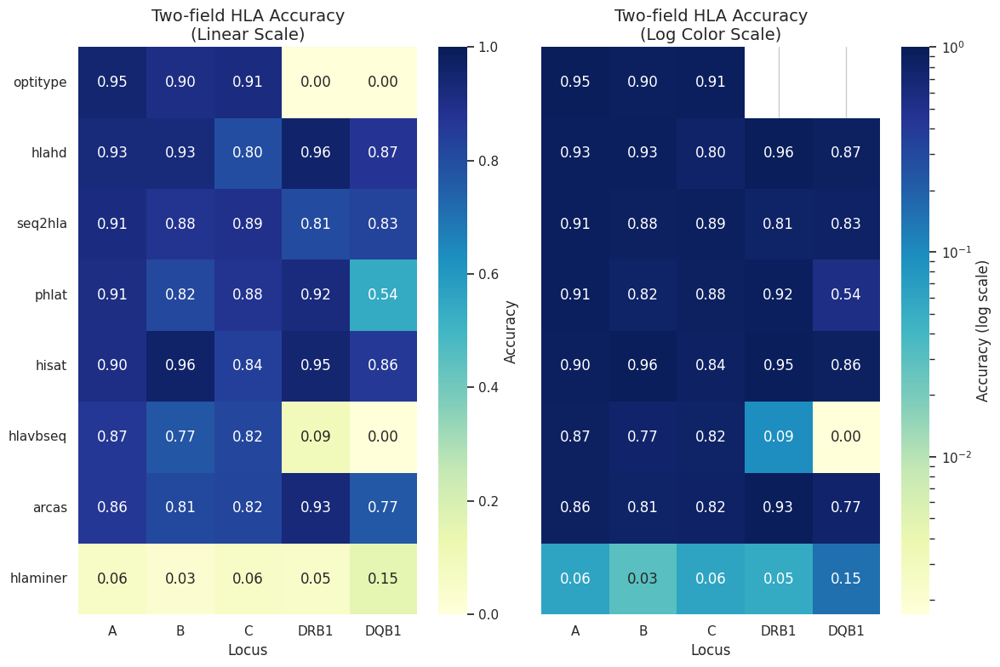

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- assume df_locus_all is ready ---
loci_order = ["A","B","C","DRB1","DQB1"]
df_pivot = (
    df_locus_stats
    .pivot(index="Tool", columns="Locus", values="Accuracy")
    .reindex(columns=loci_order)
    .fillna(0.0)
    .sort_values(by="A", ascending=False)
)

mask_zeros = (df_pivot == 0.0)
nonzero = df_pivot[df_pivot > 0]
min_nonzero = nonzero.min().min() if not nonzero.empty else 1e-3

vmin_linear, vmax = 0.0, 1.0
vmin_log = max(min_nonzero, 1e-3)

sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=False)

# 1) Linear
sns.heatmap(
    df_pivot,
    ax=ax1,
    cmap="YlGnBu",
    vmin=vmin_linear, vmax=vmax,
    annot=True, fmt=".2f",
    cbar_kws={"label":"Accuracy"},
    yticklabels=df_pivot.index,  # draw the tool names
    xticklabels=True
)
ax1.set_title("Two-field HLA Accuracy\n(Linear Scale)", fontsize=14)
ax1.set_xlabel("Locus", fontsize=12)
ax1.set_ylabel("")  
ax1.tick_params(axis='y', rotation=0, labelsize=11)

# 2) Log scale
sns.heatmap(
    df_pivot,
    ax=ax2,
    cmap="YlGnBu",
    norm=mcolors.LogNorm(vmin=vmin_log, vmax=vmax),
    annot=True, fmt=".2f",
    cbar_kws={"label":"Accuracy (log scale)"},
    mask=mask_zeros,
    yticklabels=False,          # hide labels on right only
    xticklabels=True
)
ax2.set_title("Two-field HLA Accuracy\n(Log Color Scale)", fontsize=14)
ax2.set_xlabel("Locus", fontsize=12)
ax2.set_ylabel("")

plt.tight_layout()
plt.show()






## Figure 6: Miscalled Alleles  at each locus for each tool

### counts plot

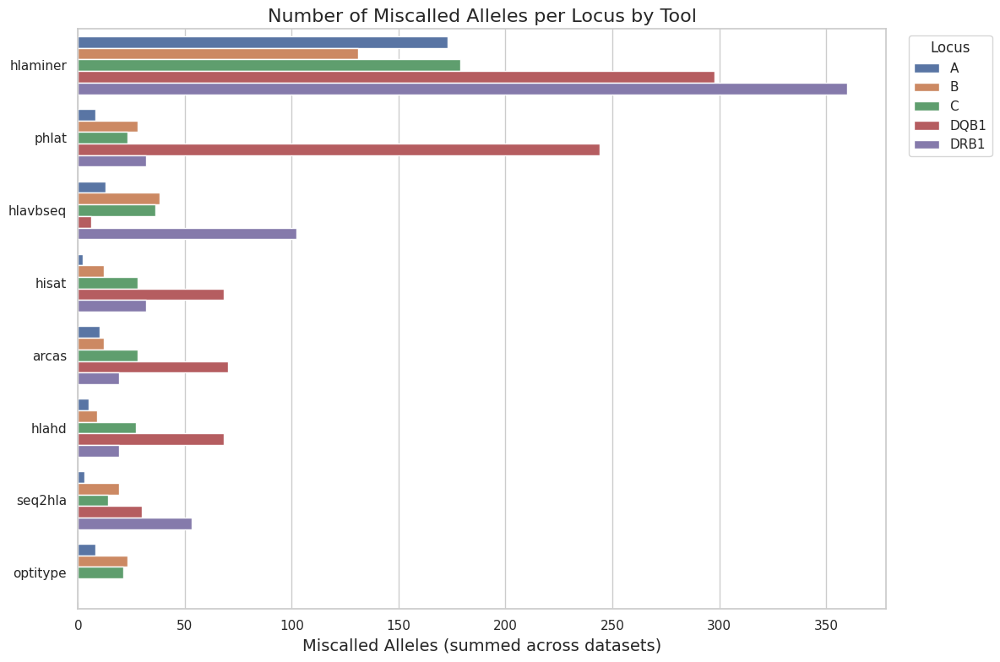

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assume df_locus_stats is already computed and has columns:
# Tool | Locus | CorrectAlleles | MiscalledAlleles | NoCallAlleles | TotalAlleles | Accuracy

# 1) order tools by total miscalls descending (so largest appear at top)
tool_order = (
    df_locus_stats
    .groupby("Tool")["MiscalledAlleles"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# 2) set up the plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 3) grouped horizontal barplot: one bar per (tool, locus)
ax = sns.barplot(
    data=df_locus_stats,
    y="Tool",
    x="MiscalledAlleles",
    hue="Locus",
    order=tool_order,
    dodge=True
)

# 4) styling
ax.set_title("Number of Miscalled Alleles per Locus by Tool", fontsize=16)
ax.set_xlabel("Miscalled Alleles (summed across datasets)", fontsize=14)
ax.set_ylabel("")  # no need for y‐label since names are on the axis
ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### proportion plots

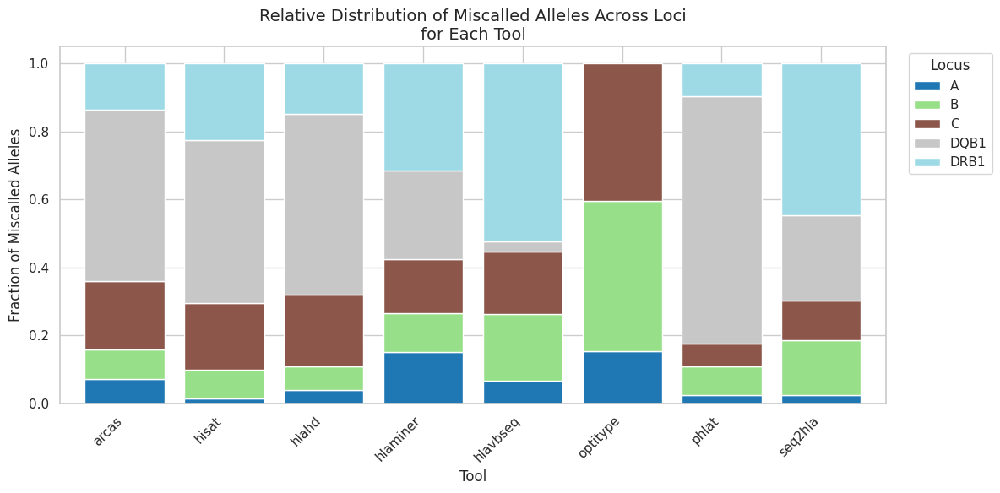

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# --- assume df_locus_stats is already in memory, with columns:
# Tool | Locus | CorrectAlleles | MiscalledAlleles | NoCallAlleles

# 1) compute total miscalls per tool
df = df_locus_stats.copy()
df["TotalMis"] = df.groupby("Tool")["MiscalledAlleles"].transform("sum")

# 2) compute fraction per locus
df["FracMis"] = df["MiscalledAlleles"] / df["TotalMis"]

# 3) pivot so each Tool is a row, columns are Loci, values are the fraction
df_frac = df.pivot(index="Tool", columns="Locus", values="FracMis").fillna(0)

# 4) plot as 100% stacked bar chart
ax = df_frac.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="tab20",
    width=0.8
)

ax.set_ylabel("Fraction of Miscalled Alleles", fontsize=12)
ax.set_xlabel("Tool", fontsize=12)
ax.set_title("Relative Distribution of Miscalled Alleles Across Loci\nfor Each Tool", fontsize=14)
ax.legend(title="Locus", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### ridge plot 

In [58]:
import pandas as pd

def single_tool_dataset_stats(tool: str,
                              ds: int,
                              resolution: int = 2,
                              filter_option: bool = False) -> pd.DataFrame:
    """
    Returns a DataFrame with one row per locus for the given (tool, dataset)
    with columns: Tool, Dataset, Locus, MiscalledAlleles
    """
    # reuse your existing logic, but restricted to a single tool & dataset
    gs_file  = f"../datasets/{ds}_gs.csv"
    pre_file = f"../results/standard/{tool}_d{ds}.csv"

    # attempt to read; if missing, return empty
    try:
        import os
        if not (os.path.exists(gs_file) and os.path.exists(pre_file)):
            return pd.DataFrame([], columns=["Tool","Dataset","Locus","MiscalledAlleles"])
        gs_df  = pd.read_csv(gs_file)
        pre_df = pd.read_csv(pre_file)
    except Exception:
        return pd.DataFrame([], columns=["Tool","Dataset","Locus","MiscalledAlleles"])

    # derive loci dynamically
    loci = [c.split(".")[0] for c in gs_df.columns[1:]]
    loci = sorted(set(loci))

    # build valid‐allele set if filtering
    valid = {}
    if filter_option:
        for locus in loci:
            vals = (
                gs_df
                .filter(regex=f"^{locus}(\\.1)?$")
                .astype(str)
                .stack()
                .dropna()
            )
            s = set()
            for v in vals:
                for a in v.split("/"):
                    s.add(a.strip().split()[0])  # no reformat needed here
            valid[locus] = s

    # merge on sample ID
    id_col = gs_df.columns[0]
    merged = pd.merge(
        gs_df, pre_df,
        left_on=id_col, right_on="ERR",
        suffixes=("_gs","_pre"),
        how="inner"
    )

    rows = []
    for _, row in merged.iterrows():
        for locus in loci:
            # gather gold‐standard alleles
            graw = []
            for col in (f"{locus}_gs", f"{locus}.1_gs"):
                if col in row and pd.notna(row[col]):
                    graw += [x.strip() for x in str(row[col]).split("/")]
            if not graw:
                continue
            gset = set(graw)
            if len(gset) > 2:
                # skip phase ambiguous 
                continue

            # gather predicted alleles
            praw = []
            for col in (f"{locus}_pre", f"{locus}.1_pre"):
                if col in row and pd.notna(row[col]):
                    praw += [x.strip() for x in str(row[col]).split("/")]
            if len(praw) == 0:
                # two no‐calls
                mis = 0
            else:
                if len(praw) == 1:
                    praw = praw*2
                else:
                    praw = praw[:2]
                if filter_option:
                    vs = valid.get(locus, set())
                    praw = [p for p in praw if p in vs]
                # miscalls = predictions not in GS set
                mis = sum(1 for p in praw if p not in gset)

            rows.append({
                "Tool": tool,
                "Dataset": ds,
                "Locus": locus,
                "MiscalledAlleles": mis
            })

    return pd.DataFrame(rows)

def build_miscalled_df(tools, dataset_nums, resolution=2, filter_option=False):
    """
    Loops over all tools & datasets and stacks their per‐locus mis‐call counts.
    """
    dfs = []
    for tool in tools:
        for ds in dataset_nums:
            df_sd = single_tool_dataset_stats(tool, ds, resolution, filter_option)
            dfs.append(df_sd)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame([], columns=["Tool","Dataset","Locus","MiscalledAlleles"])

# Usage
tools = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat","rna2hla","hlaforest"]
datasets = list(range(1,9))
df_mis_by_ds = build_miscalled_df(tools, datasets,
                                  resolution=2,
                                  filter_option=True)


/tmp/ipykernel_258659/1871467657.py:34: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_258659/1871467657.py:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_258659/1871467657.py:34: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_258659/1871467657.py:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_258659/1871467657.py:34: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_258659/1871467657.py:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable thi

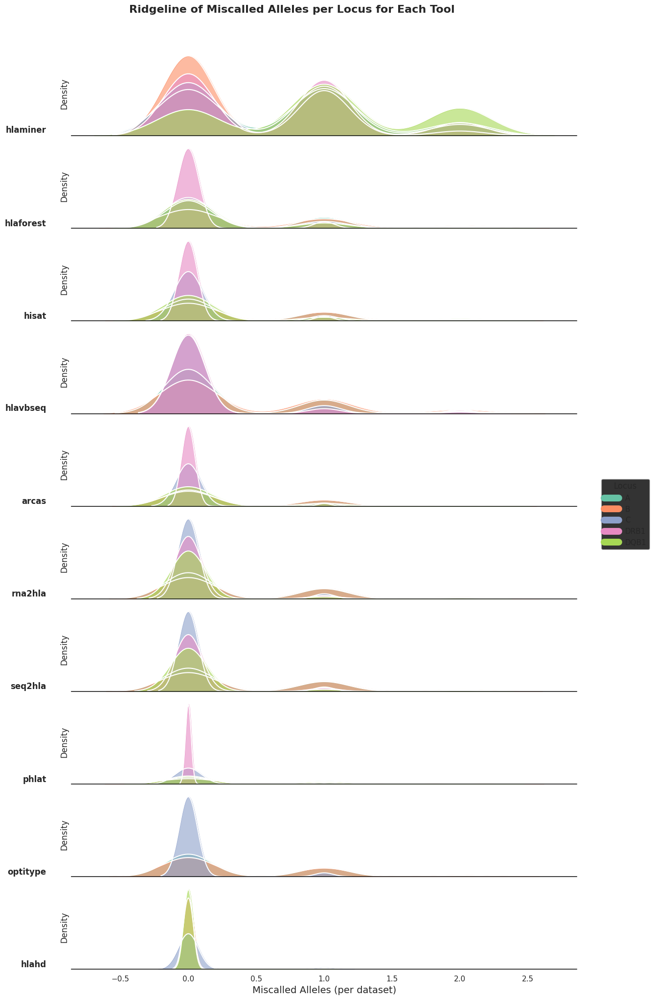

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# make sure df_mis_by_ds has data
assert not df_mis_by_ds.empty, "No data to plot!"

# order your tools by total miscalls descending
tool_order = (
    df_mis_by_ds
    .groupby("Tool")["MiscalledAlleles"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# define your loci and colors
loci = ["A","B","C","DRB1","DQB1"]
palette = sns.color_palette("Set2", n_colors=len(loci))
locus_colors = dict(zip(loci, palette))

# set up the figure
sns.set_theme(style="white", rc={"axes.facecolor": (0,0,0,0)})
fig, axes = plt.subplots(len(tool_order), 1,
                         figsize=(12, 2*len(tool_order)),
                         sharex=True)

for ax, tool in zip(axes, tool_order):
    sub = df_mis_by_ds[df_mis_by_ds.Tool == tool]
    for locus in loci:
        vals = sub.loc[sub.Locus==locus, "MiscalledAlleles"]
        if len(vals) < 2:
            continue
        sns.kdeplot(
            data=vals,
            ax=ax,
            fill=True,
            alpha=0.6,
            bw_adjust=1,
            linewidth=1.5,
            color=locus_colors[locus]
        )
        sns.kdeplot(
            data=vals,
            ax=ax,
            color="white",
            lw=1.5,
            bw_adjust=1
        )

    ax.axhline(0, color="k", lw=1)
    ax.text(-0.05, 0.02, tool,
            transform=ax.get_yaxis_transform(),
            ha="right", va="bottom",
            fontweight="bold")
    ax.set_yticks([])
    for spine in ["top","right","left"]:
        ax.spines[spine].set_visible(False)

# common x‐label and legend
axes[-1].set_xlabel("Miscalled Alleles (per dataset)", fontsize=14)

handles = [plt.Line2D([], [], color=locus_colors[l], lw=10) for l in loci]
fig.legend(handles, loci, title="Locus",
           bbox_to_anchor=(1.02, 0.5),
           loc="center left")

fig.suptitle("Ridgeline of Miscalled Alleles per Locus for Each Tool",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Figure 7: Misclassification rate of alleles 

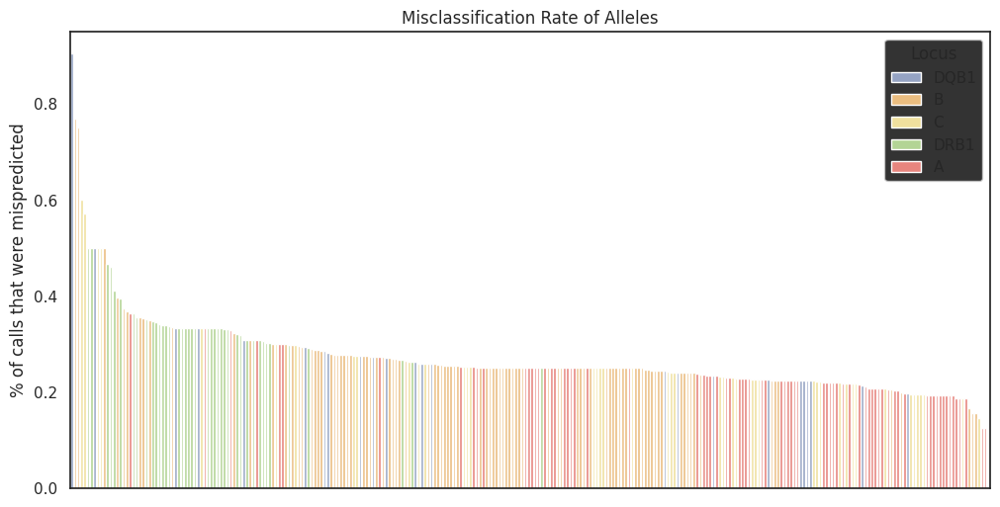

In [78]:
# Now you can plug df_misclassified into your barplot code:
import seaborn as sns, matplotlib.pyplot as plt

df_sorted = df_misclassified

custom_palette = {
    "A":     "#F8766D",
    "B":     "#FCBF6E",
    "C":     "#FEE890",
    "DRB1":  "#B2DF8A",
    "DQB1":  "#8DA0CB"
}

plt.figure(figsize=(12,6))
sns.barplot(
    x=df_sorted.index,
    y="MisclassificationRate",
    hue="Locus",
    data=df_sorted,
    palette=custom_palette
)
plt.title("Misclassification Rate of Alleles")
plt.ylabel("% of calls that were mispredicted")
plt.xlabel("")
plt.xticks([],[])
plt.legend(title="Locus", loc="best")
plt.show()


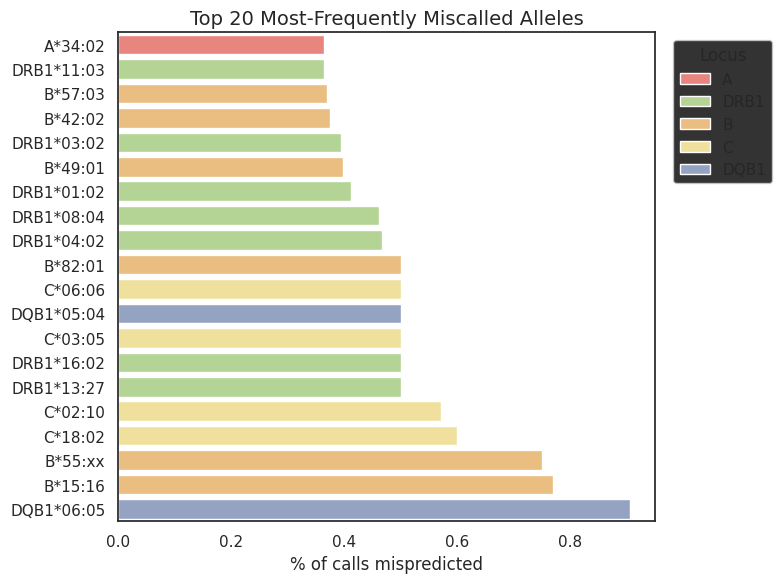

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assume df_misclassified has columns:
#   Locus | Allele | MisclassificationRate

# 1) pick the top N
N = 20
df_top = df_misclassified.nlargest(N, "MisclassificationRate").copy()

# 2) sort so the biggest is at the top of the horizontal bar chart
df_top = df_top.sort_values("MisclassificationRate", ascending=True)

# 3) define a small palette for your five loci
pal = {
    "A":     "#F8766D",
    "B":     "#FCBF6E",
    "C":     "#FEE890",
    "DRB1":  "#B2DF8A",
    "DQB1":  "#8DA0CB"
}

# 4) plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x="MisclassificationRate",
    y="Allele",
    hue="Locus",
    data=df_top,
    palette=pal,
    dodge=False   # all on the same bars
)

plt.xlabel("% of calls mispredicted", fontsize=12)
plt.ylabel("")  # allele names down the side
plt.title(f"Top {N} Most‐Frequently Miscalled Alleles", fontsize=14)
plt.xlim(0, df_top.MisclassificationRate.max()*1.05)
plt.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Annotate

### hla.dat annotation

In [ ]:
from Bio import SeqIO

# Download latest HLA.dat from https://github.com/ANHIG/IMGTHLA
hla_dat_path = "../datasets/hla.dat"

# Parse HLA.dat entries
hla_entries = {}
for record in SeqIO.parse(hla_dat_path, "imgt"):
    allele_name=record.description.split(",")[0]
    try:
        field_2= allele_name.split(":")[0]+":"+allele_name.split(":")[1]
    except IndexError:
        #print(record.description)
        continue
    #allele_name = record.id.split('*')[0] + '*' + record.id.split('*')[1]
    hla_entries[field_2] = {
        'description': record.description,
        'sequence': str(record.seq),
        'features': record.features
    }

# Example annotation lookup
#allele = 'HLA-A*02:01'
#print(hla_entries[allele]['description'])  # Outputs functional details


ID: HLA00001.4
Name: HLA00001
Description: HLA-A*01:01:01:01, Human MHC Class I sequence
Database cross-references: EMBL:AJ278305, EMBL:AL645935, EMBL:CR759913, EMBL:EU445470, EMBL:GU812295, EMBL:HG794373, EMBL:M24043, EMBL:OR126295, EMBL:OZ079919, EMBL:X55710, EMBL:Z93949
Number of features: 19
/sequence_version=4
/molecule_type=DNA
/data_file_division=HUM
/accessions=['HLA00001']
/keywords=['Human MHC', 'HLA', 'Class I', 'HLA-A', 'Allele', 'HLA-A*01:01:01:01']
/organism=Homo Sapiens (human)
/taxonomy=['Eukaryota', 'Metazoa', 'Chordata', 'Vertebrata', 'Mammalia', 'Eutheria', 'Primates', 'Catarrhini', 'Hominidae', 'Homo']
/comment=--------------------------------------------------------------------------
IPD-IMGT/HLA Release Version 3.60.0
--------------------------------------------------------------------------
Copyrighted by the IPD-IMGT/HLA Database, Distributed under the Creative
Commons Attribution-NoDerivs License, see;
http://www.ebi.ac.uk/ipd/imgt/hla/licence/ for further deta

KeyboardInterrupt: 

In [122]:

df_misclassified_copy = df_misclassified.copy()
for allele in df_misclassified_copy['Allele'].unique():
    corrected_allele = f"HLA-{allele}"
    if corrected_allele in hla_entries:
        df_misclassified_copy.loc[df_misclassified_copy['Allele'] == allele, 'Description'] = hla_entries[corrected_allele]['description'].split(",")[1]
        # Print the allele details
        print(f"Allele: {allele}")
        print("Description:", hla_entries[corrected_allele]['description'])
        print("Sequence:", hla_entries[corrected_allele]['sequence'])
        print()
    else:
        print(f"Allele {allele} not found in HLA.dat")

Allele: DQB1*06:05
Description: HLA-DQB1*06:05:02, Human MHC Class II sequence (partial)
Sequence: GGACGGAGCGCGTGCGTCTTGTAACCAGATACATCTATAACCGAGAGGAGTACGCGCGCTTCGACAGCGACGTGGGGGTGTACCGGGCGGTGACGCCGCAGGGGCGGCCTGTCGCCGAGTACTGGAACAGCCAGAAGGAAGTCCTGGAGAGGACCCGGGCGGAGTTGGACACG

Allele: B*15:16
Description: HLA-B*15:16:05, Human MHC Class I sequence
Sequence: GATCAGGACGAAGTCCCAGGTCCCGGACGGGGCTCTCAGGGTCTCAGGCTCCGAGAGCCTTGTCTGCATTGGGGAGGCGCAGCGTTGGGGATTCCCCACTCCCACGAGTTTCACTTCTTCTCCCAACCTATGTCGGGTCCTTCTTCCAGGATACTCGTGACGCGTCCCCATTTCCCACTCCCATTGGGTGTCGGGTGTCTAGAGAAGCCAATCAGTGTCGCCGGGGTCCCAGTTCTAAAGTCCCCACGCACCCACCCGGACTCAGAATCTCCTCAGACGCCGAGATGCGGGTCACGGCGCCCCGAACCGTCCTCCTGCTGCTCTCGGGAGCCCTGGCCCTGACCGAGACCTGGGCCGGTGAGTGCGGGTCGGGAGGGAAATGGCCTCTGTGGGGAGGAGCGAGGGGACCGCAGGCGGGGGCGCAGGACCCGGGGAGCCGCGCCGGGAGGAGGGTCGGGCGGGTCTCAGCCCCTCCTCGCCCCCAGGCTCCCACTTCATGAGGTATTTCTACACCGCCATGTCCCGGCCCGGCCGCGGGGAGCCCCGCTTCATCGCAGTGGGCTACGTGGACGACACGCAGTTCGTGAGGTTCGACAGCGACGCCGCGAGTCCGAGGATGGCGCCCCGGGCGCCATGGATAGAGC

### api annotation

In [149]:
import requests
from collections import defaultdict

def process_hla_api_response(response):
    """Processes raw API response into structured biological annotations"""
    if response.status_code != 200:
        return None
        
    data = response.json()
    annotations = defaultdict(lambda: None)
    
    if data['data']:
        entry = data['data'][0]
        annotations.update({
            'allele': entry['name'],
            'secondary_name': entry.get('secondary_name'),
            'expression': entry.get('expression.description'),
            'kir_ligand': entry.get('matching.kir_ligand'),
            'population_freq': {k.split('.')[-1]: v 
                               for k, v in entry.items() 
                               if k.startswith('cwd.version_3.')},
            'pubmed_ids': entry.get('citations.pubmed', []),
            'accession': entry['accession']
        })
    
    return annotations

def get_biological_context(allele):
    """Main function to retrieve HLA biological context"""
    params = {
        "query": f'{{"name":"{allele}"}}',
        "fields": "accession,name,citations.pubmed,cwd.version_3.*,expression.description,matching.kir_ligand",
        "limit": 1
    }
    
    try:
        response = requests.get("https://www.ebi.ac.uk/cgi-bin/ipd/api/allele", params=params)
        annotations = process_hla_api_response(response)
        
        if annotations:
            annotations['external_links'] = {
                'genbank_protein': f"https://www.ncbi.nlm.nih.gov/protein/{annotations['accession']}",
                'gwas_catalog': f"https://www.ebi.ac.uk/gwas/search?query={allele}",
                'iedb_epitopes': f"https://www.iedb.org/result_v3.php?type=mhc_ligand&mhc_allele={allele}"
            }
            
        return annotations
        
    except requests.exceptions.RequestException as e:
        print(f"API request failed: {e}")
        return None

# Usage Example
result = get_biological_context("A*01:01")
if result:
    print(f"Biological Expression: {result['expression']}")
    print(f"Population Frequencies: {result['population_freq']}")
    print(f"Research Publications: {len(result['pubmed_ids'])} linked studies")
    print(f"Protein Structure: {result['external_links']['genbank_protein']}")


Biological Expression: None
Population Frequencies: {'*': None}
Research Publications: 7 linked studies
Protein Structure: https://www.ncbi.nlm.nih.gov/protein/HLA00001


In [150]:
df_misclassified_copy = df_misclassified.copy()
for allele in df_misclassified_copy['Allele'].unique():
    result=get_biological_context(allele)
    if result:
        df_misclassified_copy.loc[df_misclassified_copy['Allele'] == allele, 'Description'] = result['expression']
        df_misclassified_copy.loc[df_misclassified_copy['Allele'] == allele, 'Population Frequencies'] = result['population_freq']
        df_misclassified_copy.loc[df_misclassified_copy['Allele'] == allele, 'Research Publications'] = len(result['pubmed_ids'])
        df_misclassified_copy.loc[df_misclassified_copy['Allele'] == allele, 'Protein Structure'] = result['external_links']['genbank_protein']
        # Print the allele details
    else:
        print(f"Allele {allele} not found in api")

0      None
1      None
2      None
3      None
4      None
       ... 
279    None
280    None
281    None
282    None
283    None
Name: Description, Length: 284, dtype: object

## Figure 8: Accuracy Against Read Length

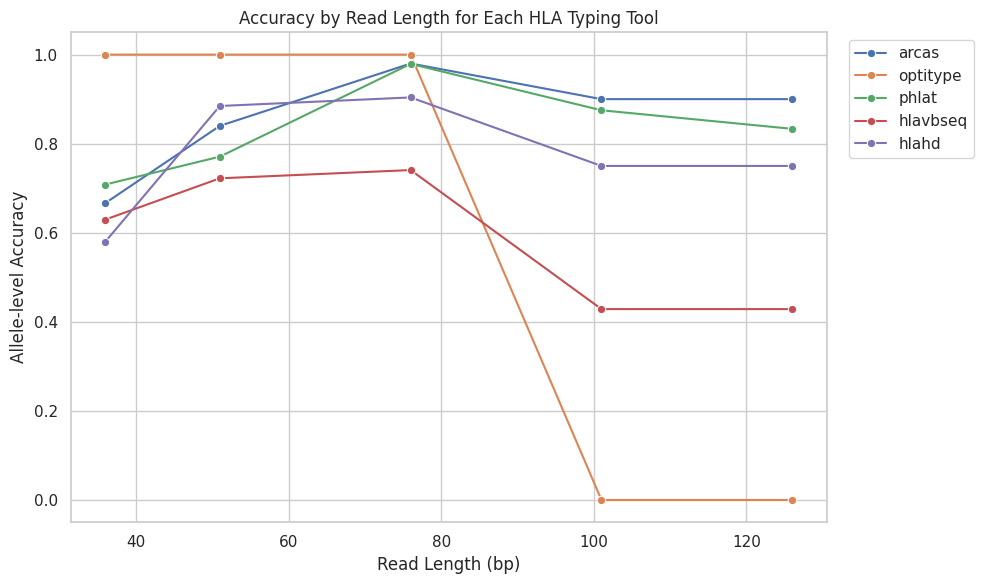

In [159]:
# simple line plot of Accuracy vs ReadLength per tool
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_rl_acc,
    x="ReadLength",
    y="Accuracy",
    hue="Tool",
    marker="o"
)
plt.title("Accuracy by Read Length for Each HLA Typing Tool")
plt.ylabel("Allele‐level Accuracy")
plt.xlabel("Read Length (bp)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()